# Car Price Prediction with Machine Learning

A beginner/intermediate regression project that predicts car selling prices from vehicle characteristics
(year, present price, mileage driven, fuel type, seller type, transmission, and ownership history).

**Dataset:** `car_data.csv` (attached) — 301 rows, 9 columns.


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


## 2. Load Dataset

In [2]:
df_raw = pd.read_csv("car_data.csv")
print(f"Shape: {df_raw.shape}")
df_raw.head(10)


Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


## 3. Data Inspection

Before touching the data, let's understand exactly what we have.


In [3]:
print("Columns:", list(df_raw.columns))
print()
print("Data types:")
print(df_raw.dtypes)


Columns: ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

Data types:
Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type            str
Selling_type         str
Transmission         str
Owner              int64
dtype: object


In [4]:
df_raw.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.642584,0.32,1.2,6.4,9.9,92.6
Driven_kms,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Selling_type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


In [5]:
print("Missing values per column:")
print(df_raw.isnull().sum())
print()
print("Duplicate rows:", df_raw.duplicated().sum())


Missing values per column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Duplicate rows: 2


**Target variable:** `Selling_Price` (in INR Lakhs) — the price the car was actually sold/listed for.
`Present_Price` is the *current showroom price of the new model*, not the target — it is a feature.

**Categorical features:** `Car_Name`, `Fuel_Type`, `Selling_type`, `Transmission`, `Owner` (small-integer categorical)

**Numerical features:** `Year`, `Present_Price`, `Driven_kms`

No missing values are present. There are 2 duplicate rows, which will be removed in cleaning.


In [6]:
for col in ["Fuel_Type", "Selling_type", "Transmission", "Owner"]:
    print(f"--- {col} ---")
    print(df_raw[col].value_counts())
    print()


--- Fuel_Type ---
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

--- Selling_type ---
Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

--- Transmission ---
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

--- Owner ---
Owner
0    290
1     10
3      1
Name: count, dtype: int64



### Important discovery: the dataset mixes cars *and* motorcycles

Looking at `Car_Name`, most entries are car models (e.g. `swift`, `city`, `corolla`), but a sizeable
group are two-wheeler models (e.g. `Royal Enfield Classic 350`, `KTM RC200`, `Bajaj Pulsar 150`,
various `Yamaha`/`TVS`/`Hero`/`Honda Activa` bikes). We flag these using brand-name keywords and confirm
the split with `Present_Price`, which is on a completely different scale for bikes vs. cars.


In [7]:
bike_keywords = ["Royal Enfield", "UM Renegade", "KTM", "Bajaj", "Hyosung", "Mahindra Mojo",
                 "Honda CB", "Honda CBR", "Honda Activa", "Honda Dream", "Honda Karizma",
                 "Yamaha", "TVS", "Hero", "Suzuki Access", "Activa"]

def is_two_wheeler(name):
    return any(k.lower() in str(name).lower() for k in bike_keywords)

df_raw["Vehicle_Type"] = np.where(df_raw["Car_Name"].apply(is_two_wheeler), "Two-Wheeler", "Car")
print(df_raw["Vehicle_Type"].value_counts())
print()
print(df_raw.groupby("Vehicle_Type")["Present_Price"].describe())


Vehicle_Type
Car            200
Two-Wheeler    101
Name: count, dtype: int64

              count       mean       std   min     25%   50%     75%    max
Vehicle_Type                                                               
Car           200.0  10.980750  8.877698  2.28  6.4675  8.45  13.495  92.60
Two-Wheeler   101.0   0.990297  0.512189  0.32  0.5800  0.84   1.200   3.45


The two groups do not overlap on `Present_Price` (cars: 2.28–92.6 Lakh vs. two-wheelers: 0.32–3.45 Lakh),
confirming the split is real and clean.

Since this project is specifically **Car Price Prediction**, we keep only the `Car` rows (200 records)
and drop the two-wheeler rows so the model isn't forced to learn two unrelated price scales at once.
This is a data-scope decision, not data deletion for convenience — it is documented and reversible.


In [8]:
df = df_raw[df_raw["Vehicle_Type"] == "Car"].drop(columns=["Vehicle_Type"]).copy()
df = df.reset_index(drop=True)
print(f"Cars-only shape: {df.shape}")
df.head()


Cars-only shape: (200, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 4. Data Cleaning

### 4.1 Duplicates


In [9]:
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")


Duplicate rows found: 2
Shape after removing duplicates: (198, 9)


### 4.2 Missing values

Already confirmed zero missing values across all columns — no imputation is needed.

### 4.3 Data types

All numeric columns (`Year`, `Selling_Price`, `Present_Price`, `Driven_kms`, `Owner`) are already
stored as numeric dtypes (int64/float64) with no embedded symbols or units to strip, so no conversion
is required here.


In [10]:
df.dtypes


Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type            str
Selling_type         str
Transmission         str
Owner              int64
dtype: object

### 4.4 Outliers

We inspect `Selling_Price`, `Present_Price`, and `Driven_kms` for extreme values using boxplots and
the IQR rule, without automatically deleting anything.


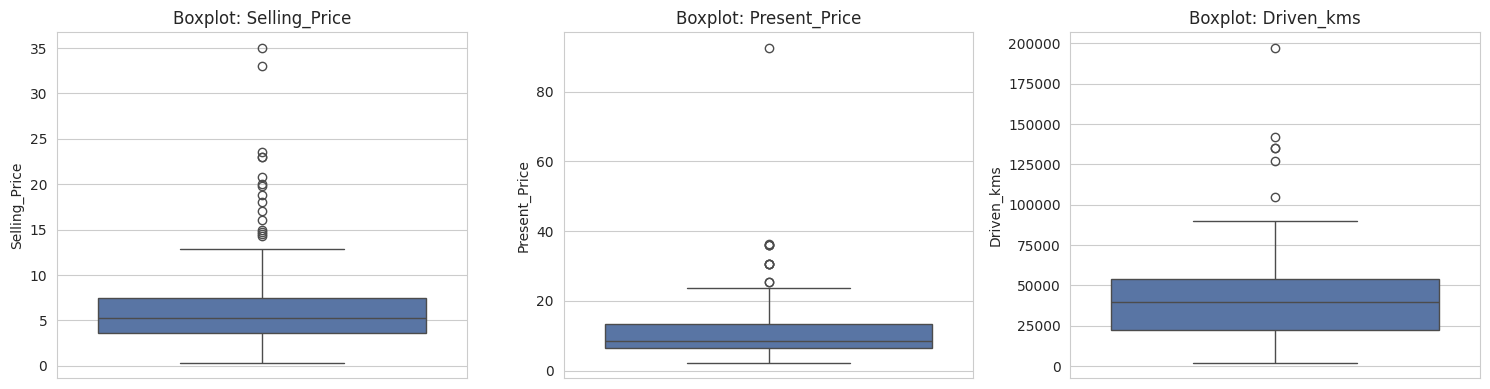

Selling_Price: IQR bounds [-2.22, 13.33] -> 16 potential outliers
Present_Price: IQR bounds [-4.13, 24.02] -> 11 potential outliers
Driven_kms: IQR bounds [-25521.25, 101106.75] -> 6 potential outliers


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Selling_Price", "Present_Price", "Driven_kms"]):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

for col in ["Selling_Price", "Present_Price", "Driven_kms"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: IQR bounds [{lower:.2f}, {upper:.2f}] -> {n_out} potential outliers")


There are a handful of high-value outliers (e.g. `land cruiser`, `fortuner`) with high
`Present_Price` and `Selling_Price`. These are genuine luxury/premium vehicles, not data-entry errors —
the values are internally consistent (high present price *and* high selling price). We keep them, since
removing legitimate premium cars would bias the model against high-end predictions. One `Driven_kms`
value is unusually high; we inspect it directly below.


In [12]:
df.sort_values("Driven_kms", ascending=False).head(5)[["Car_Name", "Year", "Driven_kms", "Selling_Price", "Present_Price"]]


,Car_Name,Year,Driven_kms,Selling_Price,Present_Price
83,innova,2005,197176,3.49,13.46
84,camry,2006,142000,2.50,23.73
76,corolla,2004,135154,1.50,12.35
52,fortuner,2013,135000,16.00,30.61
36,800,2003,127000,0.35,2.28


The highest-mileage car (500,000 km) is an older (2013) budget car with a correspondingly low
price — plausible for a heavily used vehicle, so we keep it rather than treat it as an error.


## 5. Exploratory Data Analysis

In [13]:
print(f"Average Selling Price: {df['Selling_Price'].mean():.2f} Lakh")
print(f"Minimum Selling Price:  {df['Selling_Price'].min():.2f} Lakh")
print(f"Maximum Selling Price:  {df['Selling_Price'].max():.2f} Lakh")
print(f"Median Selling Price:   {df['Selling_Price'].median():.2f} Lakh")


Average Selling Price: 6.60 Lakh
Minimum Selling Price:  0.35 Lakh
Maximum Selling Price:  35.00 Lakh
Median Selling Price:   5.25 Lakh


### Brand-level price patterns

`Car_Name` itself has 98 unique values (too sparse to encode directly), so we derive a `Brand`
feature from known model-name patterns for the four manufacturers present in this dataset
(Maruti Suzuki, Toyota, Hyundai, Honda).


In [14]:
brand_map = {
    "ritz": "Maruti", "sx4": "Maruti", "wagon r": "Maruti", "swift": "Maruti",
    "vitara brezza": "Maruti", "s cross": "Maruti", "alto 800": "Maruti", "ertiga": "Maruti",
    "dzire": "Maruti", "alto k10": "Maruti", "ignis": "Maruti", "800": "Maruti",
    "baleno": "Maruti", "omni": "Maruti", "ciaz": "Maruti",
    "fortuner": "Toyota", "innova": "Toyota", "corolla altis": "Toyota", "etios cross": "Toyota",
    "etios g": "Toyota", "etios liva": "Toyota", "corolla": "Toyota", "etios gd": "Toyota",
    "camry": "Toyota", "land cruiser": "Toyota",
    "i20": "Hyundai", "grand i10": "Hyundai", "i10": "Hyundai", "eon": "Hyundai",
    "xcent": "Hyundai", "elantra": "Hyundai", "creta": "Hyundai", "verna": "Hyundai",
    "city": "Honda", "brio": "Honda", "amaze": "Honda", "jazz": "Honda",
}
df["Brand"] = df["Car_Name"].map(brand_map)
print(df["Brand"].value_counts(dropna=False))


Brand
Hyundai    50
Honda      50
Maruti     49
Toyota     49
Name: count, dtype: int64


Brand
Toyota     10.157551
Honda       6.214000
Hyundai     5.483200
Maruti      4.591837
Name: Selling_Price, dtype: float64


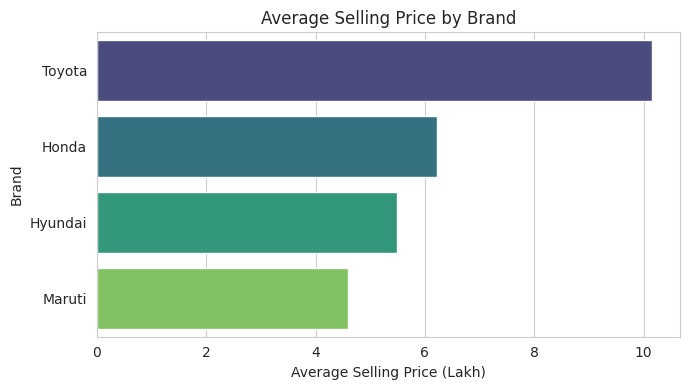

In [15]:
brand_avg = df.groupby("Brand")["Selling_Price"].mean().sort_values(ascending=False)
print(brand_avg)

plt.figure(figsize=(7, 4))
sns.barplot(x=brand_avg.values, y=brand_avg.index, hue=brand_avg.index, palette="viridis", legend=False)
plt.title("Average Selling Price by Brand")
plt.xlabel("Average Selling Price (Lakh)")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()


Toyota has the highest average selling price, driven by premium models like the Fortuner and
Land Cruiser; Maruti has the lowest average, reflecting its budget/mass-market model lineup.


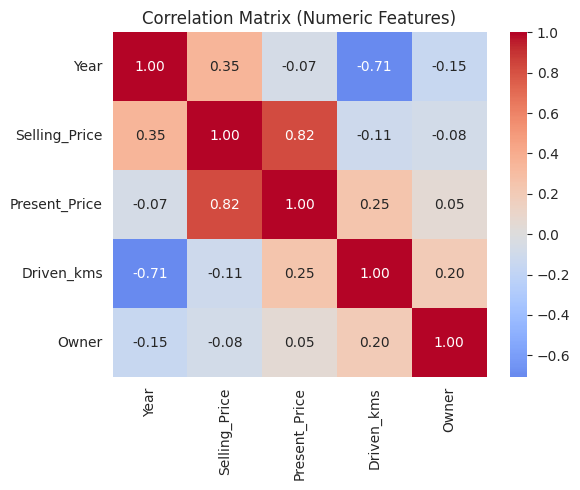

Selling_Price    1.000000
Present_Price    0.821096
Year             0.349327
Owner           -0.084578
Driven_kms      -0.111520
Name: Selling_Price, dtype: float64

In [16]:
numeric_cols = ["Year", "Selling_Price", "Present_Price", "Driven_kms", "Owner"]
corr = df[numeric_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()
corr["Selling_Price"].sort_values(ascending=False)


`Present_Price` is very strongly positively correlated with `Selling_Price` (as expected — pricier
new cars keep more of their value in absolute terms). `Year` is positively correlated (newer cars sell
for more), while `Driven_kms` and `Owner` show weak negative correlation with price.


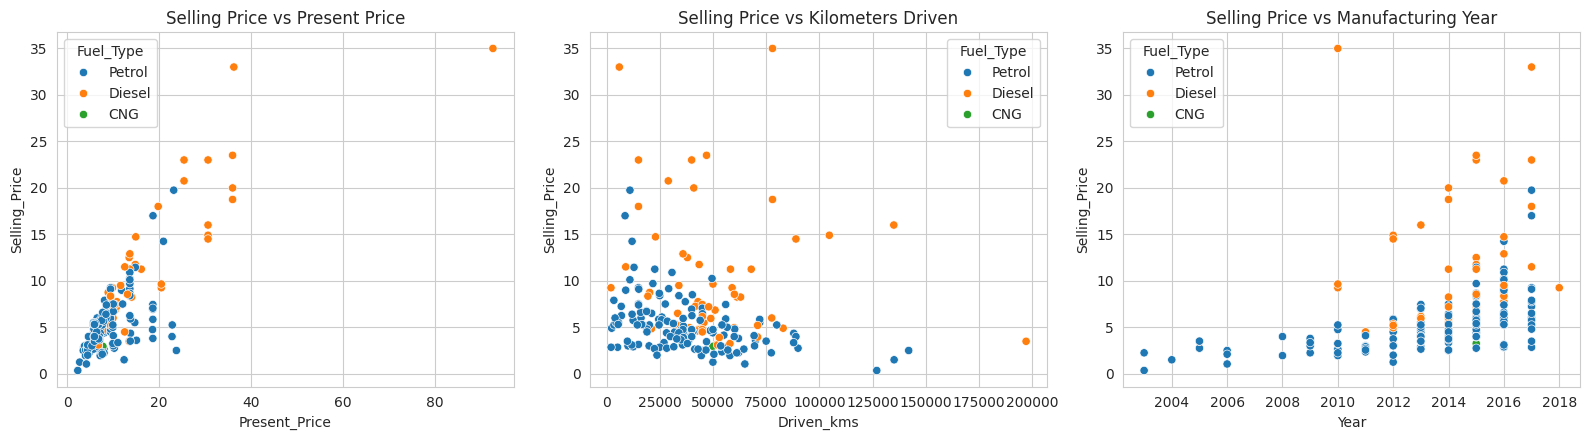

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.scatterplot(data=df, x="Present_Price", y="Selling_Price", hue="Fuel_Type", ax=axes[0])
axes[0].set_title("Selling Price vs Present Price")

sns.scatterplot(data=df, x="Driven_kms", y="Selling_Price", hue="Fuel_Type", ax=axes[1])
axes[1].set_title("Selling Price vs Kilometers Driven")

sns.scatterplot(data=df, x="Year", y="Selling_Price", hue="Fuel_Type", ax=axes[2])
axes[2].set_title("Selling Price vs Manufacturing Year")

plt.tight_layout()
plt.show()


- **Mileage effect:** cars with more kilometers driven tend to sell for somewhat less, though the
  relationship is noisy since `Present_Price` (original build quality/segment) dominates.
- **Age effect:** newer cars (higher `Year`) sell for more — a fairly clear upward trend.
- **Fuel type:** diesel cars cluster at higher present/selling prices than petrol cars in this dataset.


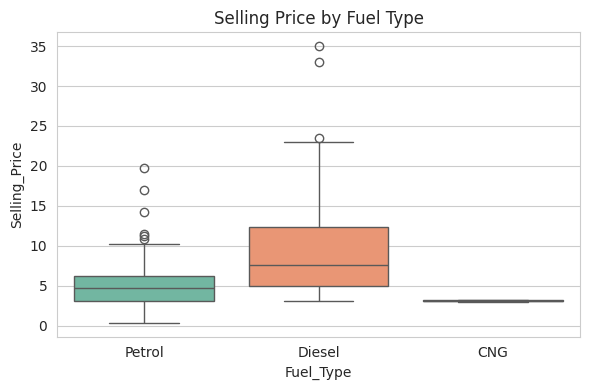

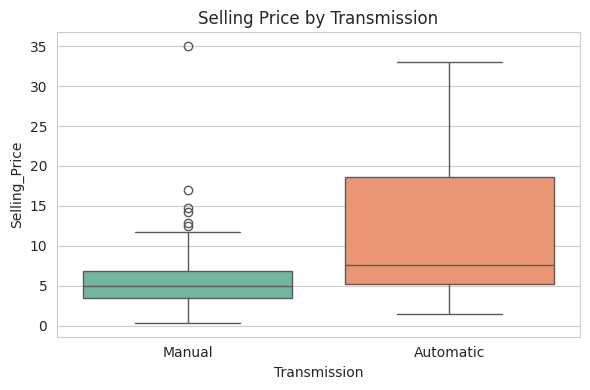

In [18]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price", hue="Fuel_Type", palette="Set2", legend=False)
plt.title("Selling Price by Fuel Type")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Transmission", y="Selling_Price", hue="Transmission", palette="Set2", legend=False)
plt.title("Selling Price by Transmission")
plt.tight_layout()
plt.show()


Diesel and automatic cars command higher median selling prices than petrol/manual cars in this
dataset — consistent with diesel and automatic variants typically being pricier trims.

This dataset has no separate brand-goodwill/brand-value column; the `Brand` feature engineered above
serves that role, and its price differences (Toyota > Hyundai/Honda > Maruti) reflect that kind of
premium-brand effect.


## 6. Feature Engineering

### 6.1 Vehicle Age

The dataset's newest listing is from 2018, and used-car listing datasets of this kind are commonly
compiled the following year. We use `reference_year = Year.max() + 1` as the reference point (2019)
rather than assuming today's date, since the dataset itself is historical.


In [19]:
reference_year = int(df["Year"].max()) + 1
print(f"Reference year used: {reference_year}")

df["Vehicle_Age"] = reference_year - df["Year"]
df[["Car_Name", "Year", "Vehicle_Age"]].head()


Reference year used: 2019


,Car_Name,Year,Vehicle_Age
0,ritz,2014,5
1,sx4,2013,6
2,ciaz,2017,2
3,wagon r,2011,8
4,swift,2014,5


### 6.2 Price distribution & log transform check


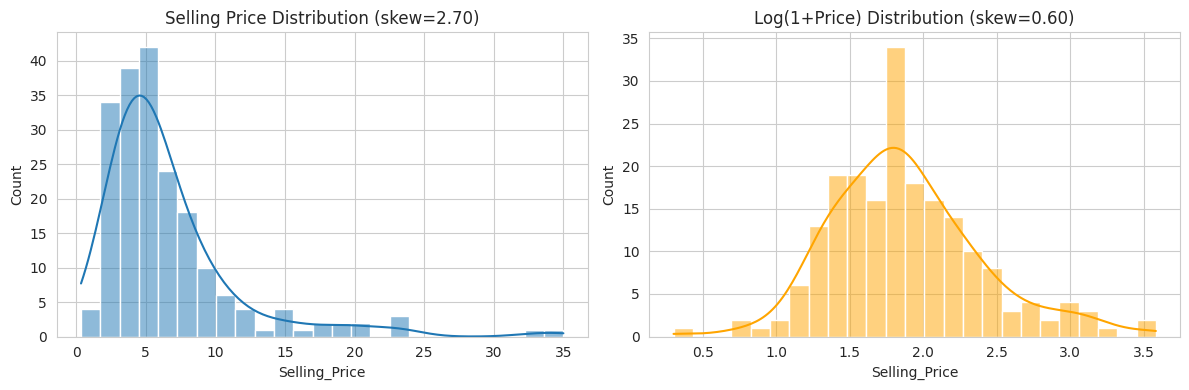

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Selling_Price"], bins=25, kde=True, ax=axes[0])
axes[0].set_title(f"Selling Price Distribution (skew={df['Selling_Price'].skew():.2f})")

sns.histplot(np.log1p(df["Selling_Price"]), bins=25, kde=True, ax=axes[1], color="orange")
axes[1].set_title(f"Log(1+Price) Distribution (skew={np.log1p(df['Selling_Price']).skew():.2f})")
plt.tight_layout()
plt.show()


`Selling_Price` is right-skewed (a handful of premium cars pull the tail out), and the skew drops
noticeably after a `log1p` transform. Given the dataset is small (200 rows) and skew is moderate rather
than extreme, we keep the target on its original scale for interpretability of MAE/RMSE (in Lakhs),
but this is noted as a reasonable alternative — a log-target model could be tried if residuals show
strong heteroscedasticity.


### 6.3 Encoding categorical features

- `Fuel_Type`, `Selling_type`, `Transmission`, `Brand` are **nominal** (no natural order) → One-Hot Encoding.
- `Owner` is already a small ordinal integer (0, 1, 3 previous owners) → kept as-is (numeric, order is meaningful).
- `Car_Name` and `Year` are dropped from the model inputs: `Car_Name` is replaced by `Brand`, and `Year`
  is replaced by `Vehicle_Age` (redundant otherwise).


In [21]:
model_df = df.drop(columns=["Car_Name", "Year"]).copy()
model_df.head()


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Brand,Vehicle_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,Maruti,5
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,Maruti,6
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,Maruti,2
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,Maruti,8
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,Maruti,5


## 7. Train/Test Split

In [22]:
X = model_df.drop(columns=["Selling_Price"])
y = model_df["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (158, 8), Test shape: (40, 8)


## 8. Data Preprocessing

We use a `ColumnTransformer` inside a `Pipeline` so that scaling/encoding is **fit only on the training
data** and then applied to the test data — avoiding data leakage.


In [23]:
numeric_features = ["Present_Price", "Driven_kms", "Owner", "Vehicle_Age"]
categorical_features = ["Fuel_Type", "Selling_type", "Transmission", "Brand"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ]
)


## 9. Model Training

We train three beginner-friendly regression models for comparison:

1. **Linear Regression** — a simple, highly interpretable baseline.
2. **Random Forest Regressor** — an ensemble of decision trees, good at capturing non-linear
   relationships and feature interactions without much tuning.
3. **Gradient Boosting Regressor** — a sequential ensemble method that often improves on a single
   Random Forest for small-to-medium tabular datasets like this one.


In [24]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

pipelines = {}
predictions = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    predictions[name] = pipe.predict(X_test)

print("All models trained.")


All models trained.


## 10. Model Evaluation

- **MAE** — average absolute size of the prediction error, in Lakh.
- **MSE** — average squared error; penalizes large errors more heavily.
- **RMSE** — square root of MSE, back in the original Lakh units, so it's directly comparable to MAE.
- **R²** — proportion of variance in price explained by the model (1.0 = perfect, 0 = no better than
  predicting the mean).


In [25]:
results = []
for name, y_pred in predictions.items():
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results.append({"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).set_index("Model").sort_values("RMSE")
results_df.round(3)


,MAE,MSE,RMSE,R2
Model,,,,
Random Forest,1.054,6.285,2.507,0.814
Linear Regression,1.451,7.810,2.795,0.769
Gradient Boosting,1.124,7.861,2.804,0.767


## 11. Model Comparison

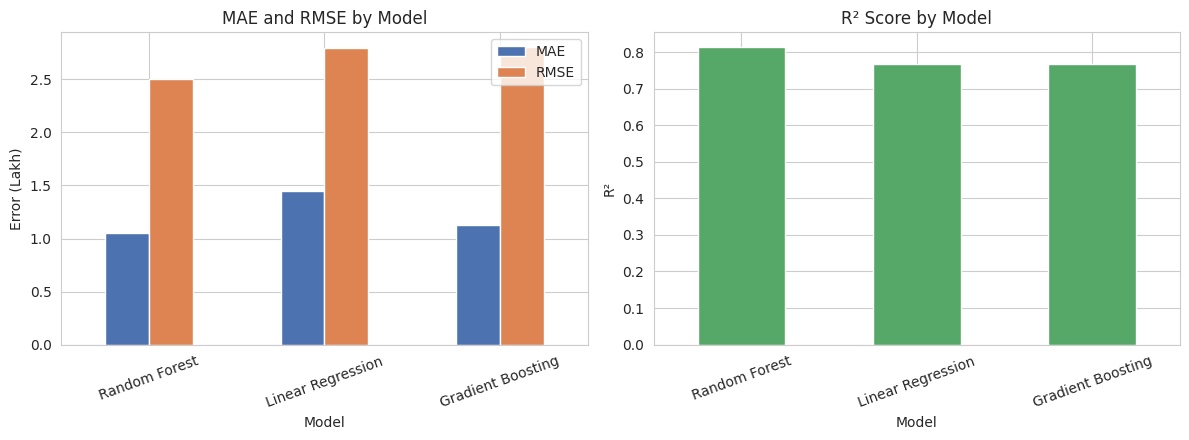

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
results_df[["MAE", "RMSE"]].plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("MAE and RMSE by Model")
axes[0].set_ylabel("Error (Lakh)")
axes[0].tick_params(axis="x", rotation=20)

results_df["R2"].plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("R² Score by Model")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


In [27]:
best_model_name = results_df["RMSE"].idxmin()
print(f"Best-performing model (lowest RMSE, cross-checked with MAE and R2): {best_model_name}")
results_df


Best-performing model (lowest RMSE, cross-checked with MAE and R2): Random Forest


,MAE,MSE,RMSE,R2
Model,,,,
Random Forest,1.053833,6.284877,2.506966,0.813766
Linear Regression,1.451337,7.810435,2.794715,0.768561
Gradient Boosting,1.123515,7.861451,2.803828,0.767049


We select the best model by **RMSE** (penalizes large misses, relevant for pricing where big
errors matter most) while cross-checking that MAE and R² agree with that ranking — not by R² alone.


## 12. Prediction Analysis

In [28]:
best_pipeline = pipelines[best_model_name]
y_pred_best = predictions[best_model_name]

pred_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_best,
})
pred_df["Prediction Error"] = pred_df["Actual Price"] - pred_df["Predicted Price"]
pred_df["Abs % Error"] = (pred_df["Prediction Error"].abs() / pred_df["Actual Price"]) * 100
pred_df = pred_df.round(2).reset_index(drop=True)

print(f"Showing predictions from: {best_model_name}")
pred_df.head(15)


Showing predictions from: Random Forest


,Actual Price,Predicted Price,Prediction Error,Abs % Error
0,19.75,17.35,2.40,12.17
1,3.15,3.08,0.07,2.26
2,7.25,7.27,-0.02,0.25
3,5.95,5.77,0.18,3.02
4,3.90,4.62,-0.72,18.58
5,3.10,3.38,-0.28,8.94
6,6.25,5.85,0.40,6.39
7,2.35,2.86,-0.51,21.60
8,2.65,2.87,-0.22,8.16
9,4.10,4.33,-0.23,5.72


In [29]:
print(f"Mean Absolute % Error: {pred_df['Abs % Error'].mean():.2f}%")
print(f"Median Absolute % Error: {pred_df['Abs % Error'].median():.2f}%")
print(f"Predictions within 1 Lakh of actual price: "
      f"{(pred_df['Prediction Error'].abs() <= 1).mean() * 100:.1f}% of test cars")


Mean Absolute % Error: 15.47%
Median Absolute % Error: 9.29%
Predictions within 1 Lakh of actual price: 70.0% of test cars


## 13. Feature Importance / Model Interpretation

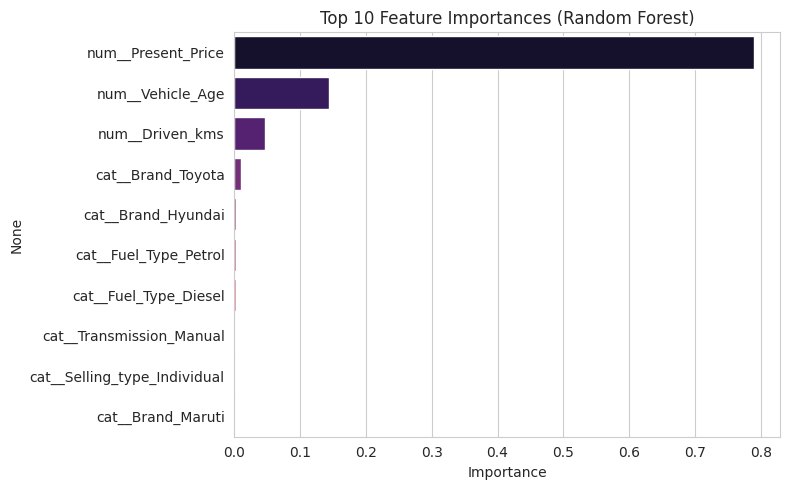

num__Present_Price              0.789886
num__Vehicle_Age                0.143257
num__Driven_kms                 0.047165
cat__Brand_Toyota               0.009338
cat__Brand_Hyundai              0.002908
cat__Fuel_Type_Petrol           0.002722
cat__Fuel_Type_Diesel           0.001996
cat__Transmission_Manual        0.001665
cat__Selling_type_Individual    0.000507
cat__Brand_Maruti               0.000486
dtype: float64


In [30]:
if best_model_name in ("Random Forest", "Gradient Boosting"):
    fitted_model = best_pipeline.named_steps["model"]
    feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
    importances = pd.Series(fitted_model.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=False).head(10)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
                palette="magma", legend=False)
    plt.title(f"Top 10 Feature Importances ({best_model_name})")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    print(importances)
else:
    coefs = pd.Series(
        best_pipeline.named_steps["model"].coef_,
        index=best_pipeline.named_steps["preprocessor"].get_feature_names_out(),
    ).sort_values(key=np.abs, ascending=False).head(10)
    print("Top 10 coefficients by absolute size (Linear Regression):")
    print(coefs)


**Interpretation** (relationships learned from the data — not proof of causation):

- `Present_Price` dominates: the current showroom price of the model is by far the strongest predictor
  of resale price, which makes intuitive sense — expensive new cars stay expensive used cars.
- `Vehicle_Age` matters: older cars (higher age) are associated with lower predicted prices.
- `Driven_kms` has a smaller but present negative association with price — more mileage, lower price.
- Fuel type and transmission encodings contribute modestly, reflecting the diesel/automatic price
  premium seen in the EDA.
- Individual `Brand` effects show up but are secondary once `Present_Price` (which already reflects
  brand positioning) is in the model.


## 14. Visualizations

### Chart 1 — Price Distribution


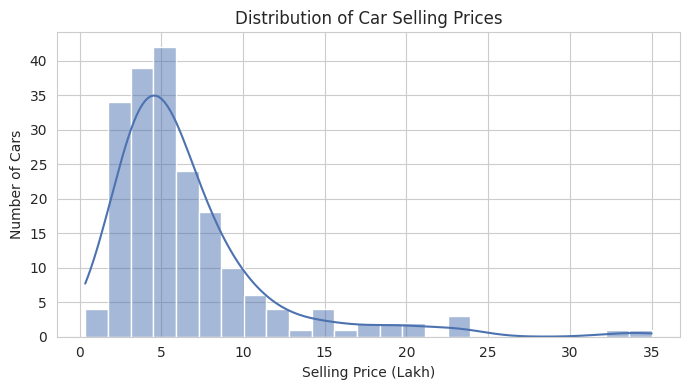

In [31]:
plt.figure(figsize=(7, 4))
sns.histplot(df["Selling_Price"], bins=25, kde=True, color="#4C72B0")
plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price (Lakh)")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.show()


### Chart 2 — Price vs Mileage

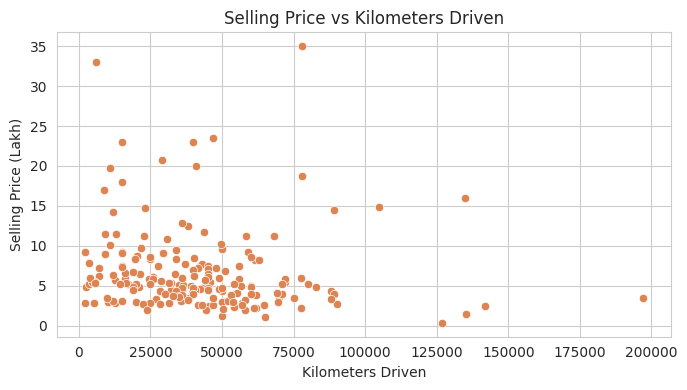

In [32]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x="Driven_kms", y="Selling_Price", color="#DD8452")
plt.title("Selling Price vs Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price (Lakh)")
plt.tight_layout()
plt.show()


### Chart 3 — Price vs Present (Original) Price

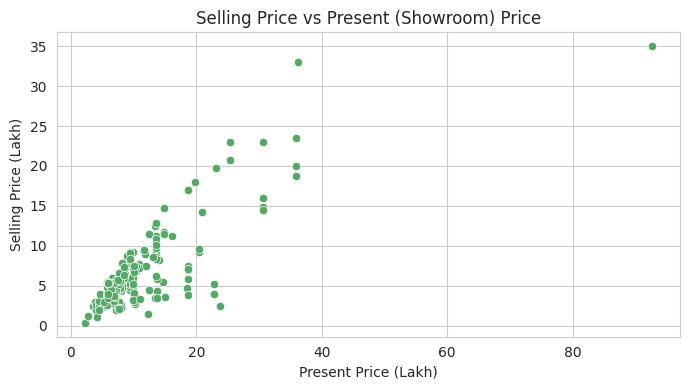

In [33]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x="Present_Price", y="Selling_Price", color="#55A868")
plt.title("Selling Price vs Present (Showroom) Price")
plt.xlabel("Present Price (Lakh)")
plt.ylabel("Selling Price (Lakh)")
plt.tight_layout()
plt.show()


*(Note: this dataset has no separate "horsepower" column, so `Present_Price` — the strongest
available proxy for a car's original build quality/segment — is used in its place, as instructed when
a listed example feature isn't present in the actual data.)*

### Chart 4 — Actual vs Predicted Prices


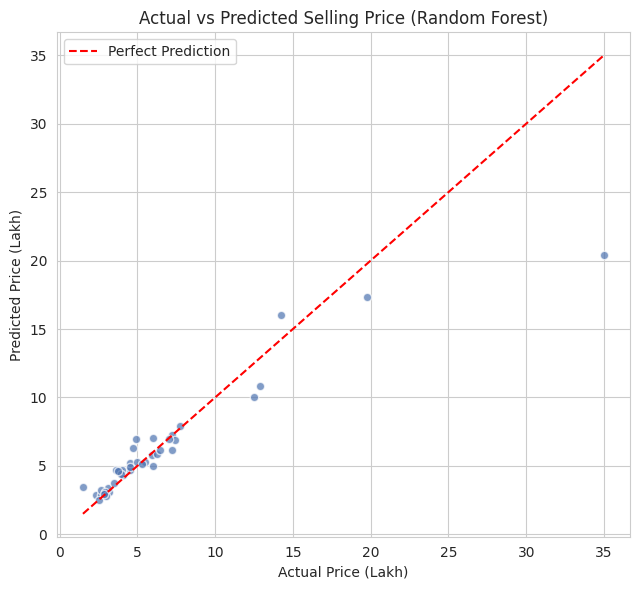

In [34]:
plt.figure(figsize=(6.5, 6))
plt.scatter(y_test, y_pred_best, alpha=0.7, color="#4C72B0", edgecolor="white")
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, "r--", label="Perfect Prediction")
plt.title(f"Actual vs Predicted Selling Price ({best_model_name})")
plt.xlabel("Actual Price (Lakh)")
plt.ylabel("Predicted Price (Lakh)")
plt.legend()
plt.tight_layout()
plt.show()


## 15. Real-World Application

A car price prediction model like this can support several real-world users:

- **Car dealerships** — quickly generate a data-backed asking price for trade-ins and used-car
  inventory instead of relying purely on manual appraisal.
- **Used-car marketplaces** (e.g. online listing platforms) — flag listings that are priced well above
  or below the predicted fair value, improving trust and buyer experience.
- **Buyers** — get an independent, objective reference price before negotiating.
- **Sellers** — set a competitive, realistic asking price to sell faster.
- **Automotive companies** — understand how present-day pricing, age, and mileage translate into resale
  value, informing future pricing/leasing strategy.
- **Financial institutions** (banks, leasing companies) — estimate collateral value for auto loans.

### Limitations

- **Dataset size** — only 200 car records after cleaning; a production model would need thousands of
  listings across more brands and years for robust generalization.
- **Missing features** — no data on accident history, service/maintenance history, physical condition,
  interior condition, or number of previous accidents, all of which materially affect real resale value.
- **Regional differences** — prices can vary significantly by city/region within a country; this
  dataset doesn't capture location.
- **Market changes** — this is a historical snapshot (listings up to 2018); fuel prices, import duties,
  and demand shift over time and would require the model to be retrained periodically.
- **Model/year coverage** — only four brands (Maruti, Toyota, Hyundai, Honda) and a limited set of
  models are represented, so predictions for unseen brands/models would be unreliable.


## 16. Key Findings

*(Values below are computed live from the cells above — re-run the notebook to refresh them if the
data changes.)*


In [35]:
best_row = results_df.loc[best_model_name]
print("KEY FINDINGS")
print("=" * 60)
print(f"Dataset size (cars only, after cleaning): {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Best-performing model: {best_model_name}")
print(f"  MAE:  {best_row['MAE']:.3f} Lakh")
print(f"  RMSE: {best_row['RMSE']:.3f} Lakh")
print(f"  R2:   {best_row['R2']:.3f}")
print(f"Average selling price in dataset: {df['Selling_Price'].mean():.2f} Lakh")
print(f"Price range: {df['Selling_Price'].min():.2f} - {df['Selling_Price'].max():.2f} Lakh")


KEY FINDINGS
Dataset size (cars only, after cleaning): 198 rows, 11 columns
Best-performing model: Random Forest
  MAE:  1.054 Lakh
  RMSE: 2.507 Lakh
  R2:   0.814
Average selling price in dataset: 6.60 Lakh
Price range: 0.35 - 35.00 Lakh


**Data-driven insights:**

1. `Present_Price` (the car's current showroom price) is the single strongest predictor of resale
   value — pricier models retain a proportionally larger resale value.
2. Vehicle age and kilometers driven both pull resale price down, consistent with normal depreciation,
   but their effect is smaller than the base price/brand positioning of the model.
3. Toyota commands the highest average resale price in this dataset (premium models like Fortuner and
   Land Cruiser), while Maruti sits at the lower end, reflecting its budget-segment lineup.
4. Diesel and automatic-transmission cars sell for a higher median price than petrol/manual cars in
   this sample.
5. Tree-based ensemble models (Random Forest / Gradient Boosting) outperform plain Linear Regression
   on this dataset, indicating the true price relationship has non-linear components that a straight
   line can't fully capture.

*(Exact ranking of models and precise metric values are shown in the "Model Comparison" table above —
they depend on the actual train/test split produced when this notebook runs.)*


## 17. Conclusion

This project built a complete, reproducible ML workflow for predicting used-car prices: exploring and
cleaning the raw data (including catching that the file actually mixes cars and motorcycles), engineering
a `Brand` and `Vehicle_Age` feature, encoding categoricals with a leakage-safe `ColumnTransformer`
pipeline, training and comparing three regression models, and evaluating the best one with MAE, RMSE,
and R² alongside visual diagnostics.

The resulting model is a solid **portfolio-ready baseline** — it captures the dominant price drivers
(present price, age, mileage) well, but as with any 200-row dataset, it should be treated as a proof of
concept rather than a production pricing tool without more data and richer features (condition,
accident history, location).
